<a href="https://colab.research.google.com/github/iam7mza/EventClassification/blob/main/FeatureSelection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# # Downloading the dataset from GitHub (uncomment when running on Colab)
# !git clone "https://github.com/iam7mza/EventClassification.git"
# !mv EventClassification/* ./
# !rm -rf EventClassification
# !rm -rf sample_data



############# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! no touch zone !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! #############
#importing data

import loader
import numpy as np
import pandas as pd

filepath = "Data" 
df = loader.load(filepath);
loader.clean(df); #to clean the data

df = df[df['numeric_target'] != -1]  #dropping all the unknown events

# Check unique event types and their corresponding targets
event_target_mapping = df[['event_type', 'numeric_target']].drop_duplicates().sort_values('numeric_target')
print("Event type to target mapping:")
print(event_target_mapping)

print(f'columns = {df.columns}')

############################################################
#########extracing features and values from lists###########
#############################################################`

# the chosen ones
# TheChosenOnes = ['trigE', 'trigM', 'trigP', 'lep_n','lep_pt', 'lep_eta', 'lep_phi',
#        'lep_E', 'lep_z0', 'lep_charge', 'lep_type', 'lep_isTightID',
#        'lep_ptcone30', 'lep_etcone20', 'lep_trackd0pvunbiased',
#        'lep_tracksigd0pvunbiased', 'met_et', 'met_phi', 'jet_n', 'jet_pt',
#        'jet_eta', 'jet_phi', 'jet_E', 'jet_jvt','jet_MV2c10', 'photon_n','photon_pt', 'photon_eta', 'photon_phi',
#        'photon_E', 'photon_isTightID', 'photon_ptcone30', 'photon_etcone20',
#        'photon_convType', 'largeRjet_n', 'largeRjet_pt', 'largeRjet_eta',
#        'largeRjet_phi', 'largeRjet_E', 'largeRjet_m','largeRjet_D2', 'largeRjet_tau32', 'tau_n', 'tau_pt', 'tau_eta',
#        'tau_phi', 'tau_E', 'tau_charge', 'tau_isTightID', 'tau_nTracks', 'tau_BDTid', 'ditau_m', 'lep_pt_syst',
#        'met_et_syst', 'jet_pt_syst', 'photon_pt_syst', 'largeRjet_pt_syst',
#        'tau_pt_syst']


TheChosenOnes = ['trigE', 'trigM', 'trigP', 'lep_n','lep_pt', 'lep_eta', 'lep_phi',
       'lep_E', 'lep_z0', 'lep_charge', 'lep_type', 'lep_isTightID',
       'lep_ptcone30', 'lep_etcone20', 'lep_trackd0pvunbiased',
       'lep_tracksigd0pvunbiased', 'met_et', 'met_phi', 'jet_n', 'jet_pt',
       'jet_eta', 'jet_phi', 'jet_E', 'jet_jvt','jet_MV2c10', 'photon_n','photon_pt', 'photon_eta', 'photon_phi',
       'photon_E', 'photon_isTightID', 'photon_ptcone30', 'photon_etcone20',
       'photon_convType', 'largeRjet_n', 'largeRjet_pt', 'largeRjet_eta',
       'largeRjet_phi', 'largeRjet_E', 'largeRjet_m','largeRjet_D2', 'largeRjet_tau32', 'tau_n', 'tau_pt', 'tau_eta',
       'tau_phi', 'tau_E', 'tau_charge', 'tau_isTightID', 'tau_nTracks', 'tau_BDTid', 'ditau_m']

#df[TheChosenOnes]

#extracting the features for lists (only first two elements)

#TODO: Turn into a function and make the number of cols an arg
# Separate list and scalar columns

def extract_list_features(df, list_cols, scalar_cols, n_elements=2):
    """
    Extract features from list columns with configurable number of elements.

    Parameters:
    df: DataFrame containing the data
    list_cols: List of column names that contain lists
    scalar_cols: List of column names that contain scalar values
    n_elements: Number of elements to extract from each list (max 5)

    Returns:
    DataFrame with extracted features
    """
    # Ensure n_elements is within valid range
    n_elements = min(max(n_elements, 1), 5)

    # Element names for readability
    element_names = ['first', 'second', 'third', 'fourth', 'fifth']

    extracted_data = {}

    # Add scalar columns
    for col in scalar_cols:
        extracted_data[col] = df[col]

    # Add list-derived columns
    for col in list_cols:
        for i in range(n_elements):
            col_name = f'{col}_{element_names[i]}'
            extracted_data[col_name] = df[col].apply(
                lambda x: x[i] if len(x) > i else np.nan
            )

    return pd.DataFrame(extracted_data)

# Usage with configurable number of elements
n_elements = 5  # Change this to extract 1-5 elements from each list

# Separate list and scalar columns
list_cols = []
scalar_cols = []

for col in TheChosenOnes:
    if col in df.columns:
        if isinstance(df[col].iloc[0], list):  # Use iloc[0] instead of [0]
            list_cols.append(col)
        else:
            scalar_cols.append(col)

print(f"List columns: {len(list_cols)}")
print(f"Scalar columns: {len(scalar_cols)}")
print(f"Extracting {n_elements} elements from each list column")

# Extract features with specified number of elements
df_extracted = extract_list_features(df, list_cols, scalar_cols, n_elements)

print(f"Shape after feature extraction: {df_extracted.shape}")

# Drop columns that are all zeros or nan
columns_to_drop = []
for col in df_extracted.columns:
    if df_extracted[col].isna().all():  # nan check
        columns_to_drop.append(col)
        print(f"Column {col} is all NaN, will drop it.")
    elif (df_extracted[col] == 0).all():  # zero check
        columns_to_drop.append(col)
        print(f"Column {col} is all zeros, will drop it.")


# Drop all NaN columns at once
if columns_to_drop:
    df_extracted = df_extracted.drop(columns=columns_to_drop)
    print(f"Dropped {len(columns_to_drop)} NaN columns")

print(f"Final shape: {df_extracted.shape}")
df_extracted

################################################################
## remving zero heavy columns ##################################
################################################################

# First, let's see what columns with _first we have
first_cols = [col for col in df_extracted.columns if '_first' in col]
print("Columns with '_first':")
print(first_cols)

# Features to compute TOTAL (sum)
total_base_features = ['lep_pt', 'lep_E', 'lep_charge', 'lep_ptcone30', 'lep_etcone20',
                      'jet_pt', 'jet_E', 'largeRjet_pt', 'largeRjet_E', 'largeRjet_m']

# Features to compute MEAN (average)
mean_base_features = ['lep_eta', 'lep_phi', 'lep_z0', 'jet_eta', 'jet_phi',
                     'largeRjet_eta', 'largeRjet_phi', 'lep_pt_syst', 'jet_pt_syst',
                     'largeRjet_pt_syst']

element_indicators = ['_first', '_second', '_third', '_fourth', '_fifth']

print("\nCreating TOTAL columns:")
# Create total columns
for base_feature in total_base_features:
    feature_cols = []
    for indicator in element_indicators:
        col_name = f'{base_feature}{indicator}'
        if col_name in df_extracted.columns:
            feature_cols.append(col_name)

    if len(feature_cols) > 0:
        total_col_name = f'{base_feature}_total'
        df_extracted[total_col_name] = df_extracted[feature_cols].sum(axis=1)
        print(f"  {total_col_name} from {len(feature_cols)} columns: {feature_cols}")

print("\nCreating MEAN columns:")
# Create mean columns
for base_feature in mean_base_features:
    feature_cols = []
    for indicator in element_indicators:
        col_name = f'{base_feature}{indicator}'
        if col_name in df_extracted.columns:
            feature_cols.append(col_name)

    if len(feature_cols) > 0:
        mean_col_name = f'{base_feature}_mean'
        # Calculate mean excluding zeros to avoid bias from missing particles

        ##TODO: Im not sure if replacing 0 with NaN is the best way to calculate mean here
        df_extracted[mean_col_name] = df_extracted[feature_cols].replace(0, np.nan).mean(axis=1, skipna=True).fillna(0)
        print(f"  {mean_col_name} from {len(feature_cols)} columns: {feature_cols}")

print(f"\nShape after adding totals and means: {df_extracted.shape}")

# Show new columns created
new_total_cols = [col for col in df_extracted.columns if '_total' in col]
new_mean_cols = [col for col in df_extracted.columns if '_mean' in col]
print(f"Added {len(new_total_cols)} total columns and {len(new_mean_cols)} mean columns")
print(f"Total columns: {new_total_cols}")
print(f"Mean columns: {new_mean_cols}")


############################################################
########### dropping nan heavy rows ########################
############################################################
#TODO: create cols with total values (for pt, E, et, etc.) such that when some cols are dropped, the total still exists

percentlim = 0.1  # 10% limit
nan_fraction = df_extracted.isna().mean(axis=0)  # Fraction of NaN values per column
high_nan_cols = nan_fraction[nan_fraction > percentlim].index.tolist()
print(f'{len(high_nan_cols)} cols are more than {percentlim*100:.0f}% NaN out of {len(df_extracted.columns)}')
print("NaN fractions per column:")
for col, frac in zip(df_extracted.columns, nan_fraction):
    if frac > 0:  # Only show columns with some NaN values
        print(f"  {col}: {frac*100:.1f}%")

df_extracted = df_extracted.drop(high_nan_cols, axis=1)
print(f'Columns remaining after dropping high-NaN columns: {len(df_extracted.columns)}')

df_extracted

#Dropping nan rows (if they exist)

nan_counts = df_extracted.isna().sum()
columns_with_nan = nan_counts[nan_counts > 0]
print(f"Columns with NaN values ({len(columns_with_nan)} out of {len(nan_counts)}):")
if len(columns_with_nan) > 0:
    for col, count in columns_with_nan.items():
        print(f"  {col}: {count}")
else:
    print("No columns have NaN values! YIPPIEEE!!")

# FIXED: Drop the same rows from both features AND targets
print(f"Shape before dropping NaN rows: {df_extracted.shape}")
rows_before = len(df_extracted)

# Get mask for rows WITHOUT any NaN values
valid_rows_mask = ~df_extracted.isna().any(axis=1)

# Apply the same mask to BOTH dataframes
df_extracted = df_extracted[valid_rows_mask]
df = df[valid_rows_mask]  # Drop same rows from targets!

rows_after = len(df_extracted)
print(f"Shape after dropping NaN rows: {df_extracted.shape}")
print(f"Dropped {rows_before - rows_after} rows with NaN values")
print(f"Target dataframe shape: {df.shape}")

# Verify alignment
print(f"Features and targets are aligned: {len(df_extracted) == len(df)}")




Found 130 CSV files
Processing: Data/Wenu_PTV280_500_CVetoBVeto_sample2000.csv
  -> Added 2000 events (event name: Wenu_PTV280_500_CVetoBVeto)
Processing: Data/Wenu_PTV140_280_CFilterBVeto_sample2000.csv
  -> Added 2000 events (event name: Wenu_PTV140_280_CFilterBVeto)
Processing: Data/Wmunu_PTV140_280_BFilter_sample2000.csv
  -> Added 2000 events (event name: Wmunu_PTV140_280_BFilter)
Processing: Data/Zee_PTV70_140_BFilter.csv
  -> Added 11 events (event name: Zee_PTV70_140_BFilter)
Processing: Data/single_antitop_tchan_sample10000.csv
  -> Added 10000 events (event name: single_antitop_tchan)
Processing: Data/C1N2_WZ_400p0_0p0_3L_2L7.csv
  -> Added 1995 events (event name: C1N2_WZ_400p0_0p0_3L_2L7)
Processing: Data/single_top_wtchan_sample10000.csv
  -> Added 10000 events (event name: single_top_wtchan)
Processing: Data/single_top_schan_sample10000.csv
  -> Added 10000 events (event name: single_top_schan)
Processing: Data/Wtaunu_PTV0_70_BFilter.csv
  -> Added 3 events (event name: W

## CORR

74


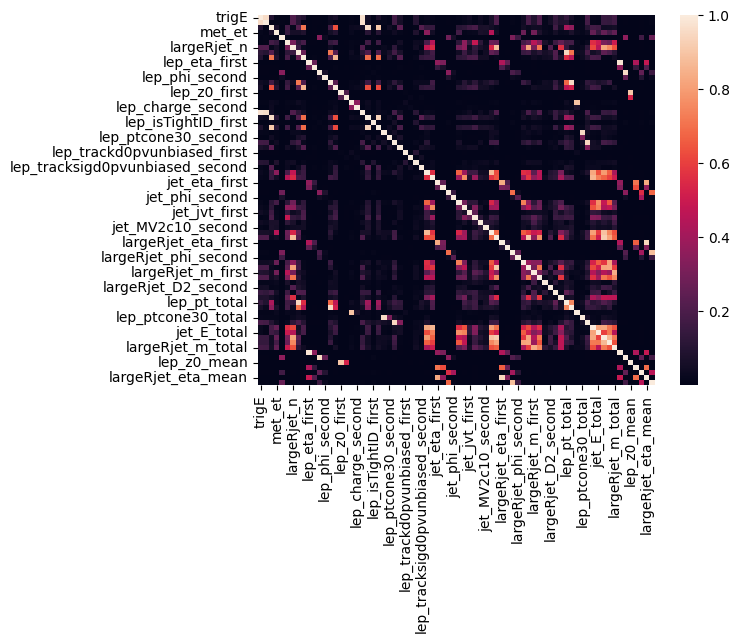

cols to drop:['trigM', 'lep_pt_second', 'lep_E_first', 'lep_E_second', 'lep_type_first', 'lep_type_second', 'lep_isTightID_second', 'jet_E_second', 'largeRjet_pt_first', 'largeRjet_pt_second', 'largeRjet_eta_first', 'largeRjet_E_first', 'largeRjet_E_second', 'largeRjet_m_second', 'lep_pt_total', 'lep_E_total', 'lep_charge_total', 'lep_ptcone30_total', 'lep_etcone20_total', 'jet_pt_total', 'jet_E_total', 'largeRjet_pt_total', 'largeRjet_E_total', 'largeRjet_m_total', 'lep_eta_mean', 'lep_phi_mean', 'lep_z0_mean', 'jet_eta_mean', 'largeRjet_eta_mean', 'largeRjet_phi_mean']
44


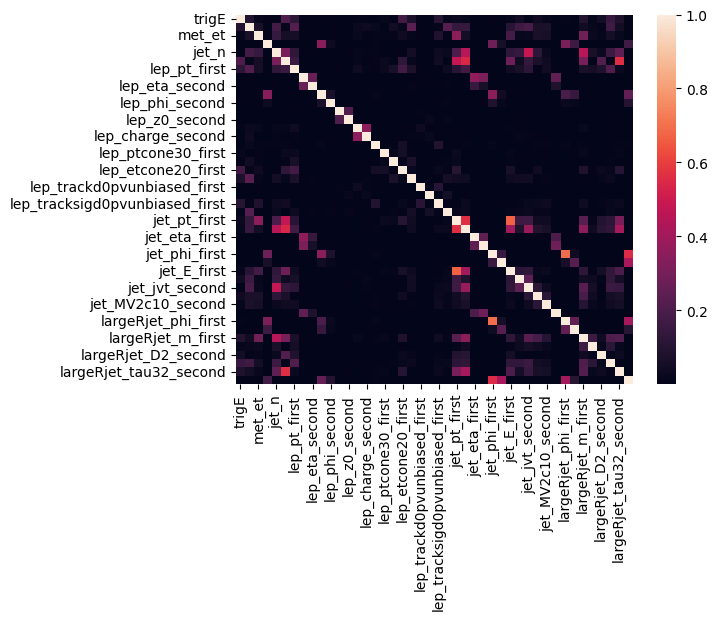

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

print(len(df_extracted.columns))
corr = df_extracted.corr().abs()
sns.heatmap(corr)
plt.show()

# Select upper triangle of correlation matrix
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Find features with correlation greater than 0.7
to_drop = [column for column in upper.columns if any(upper[column] > 0.7)]
print('cols to drop:' + str(to_drop))
# Drop features 
df_extracted.drop(to_drop, axis=1, inplace=True)

corr2 = df_extracted.corr().abs()
print(len(df_extracted.columns))
sns.heatmap(corr2)
plt.show()

## SCALING

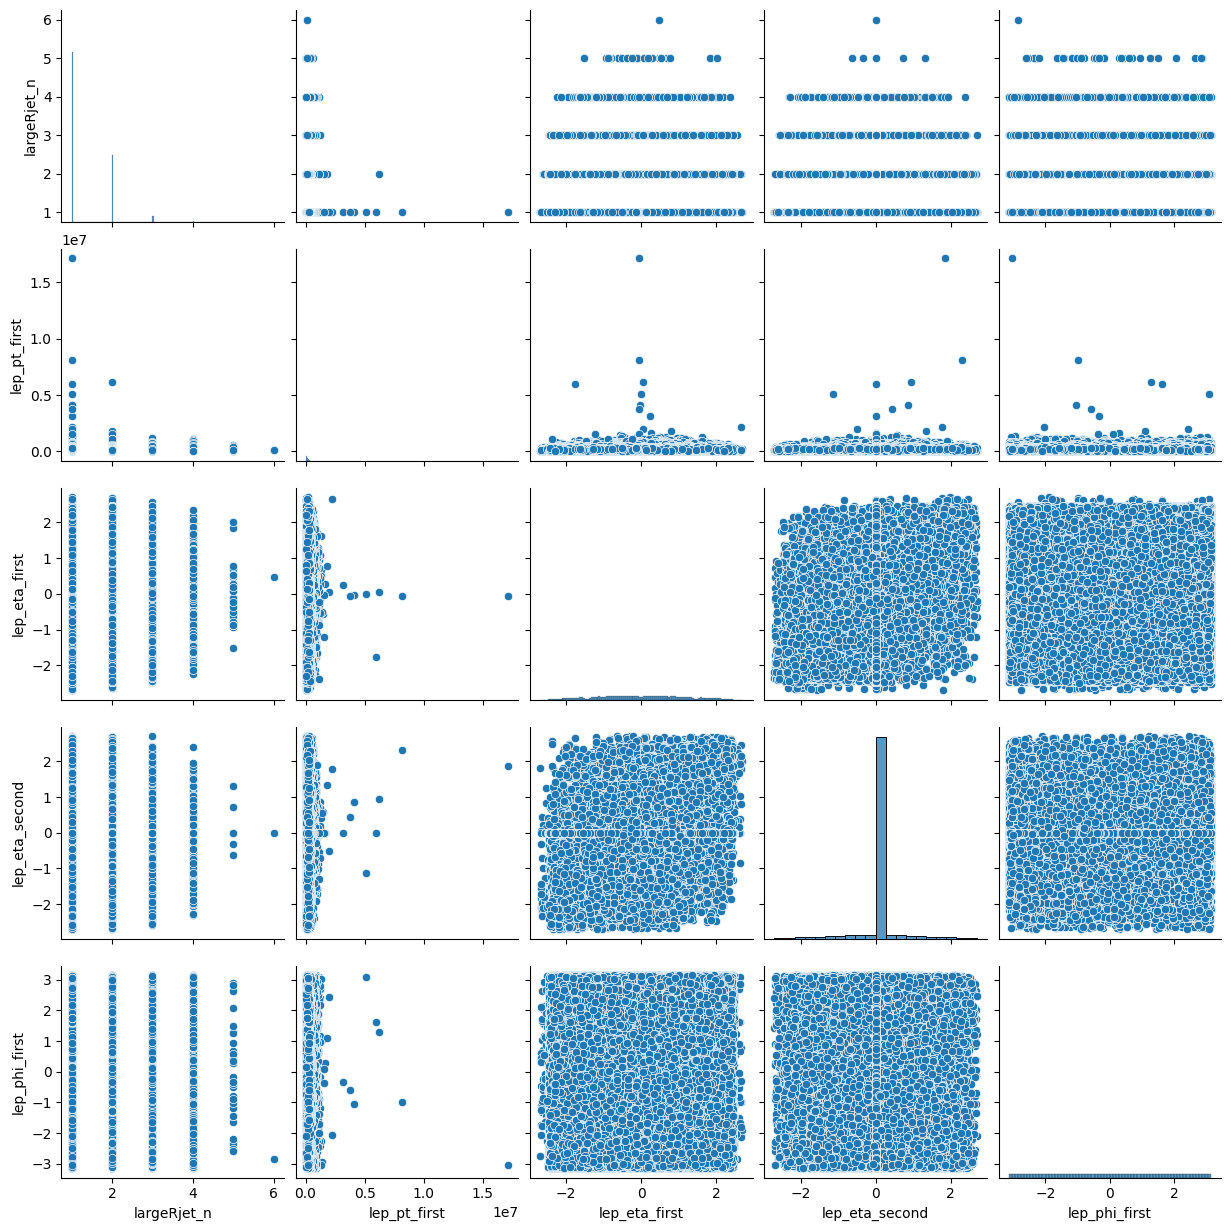

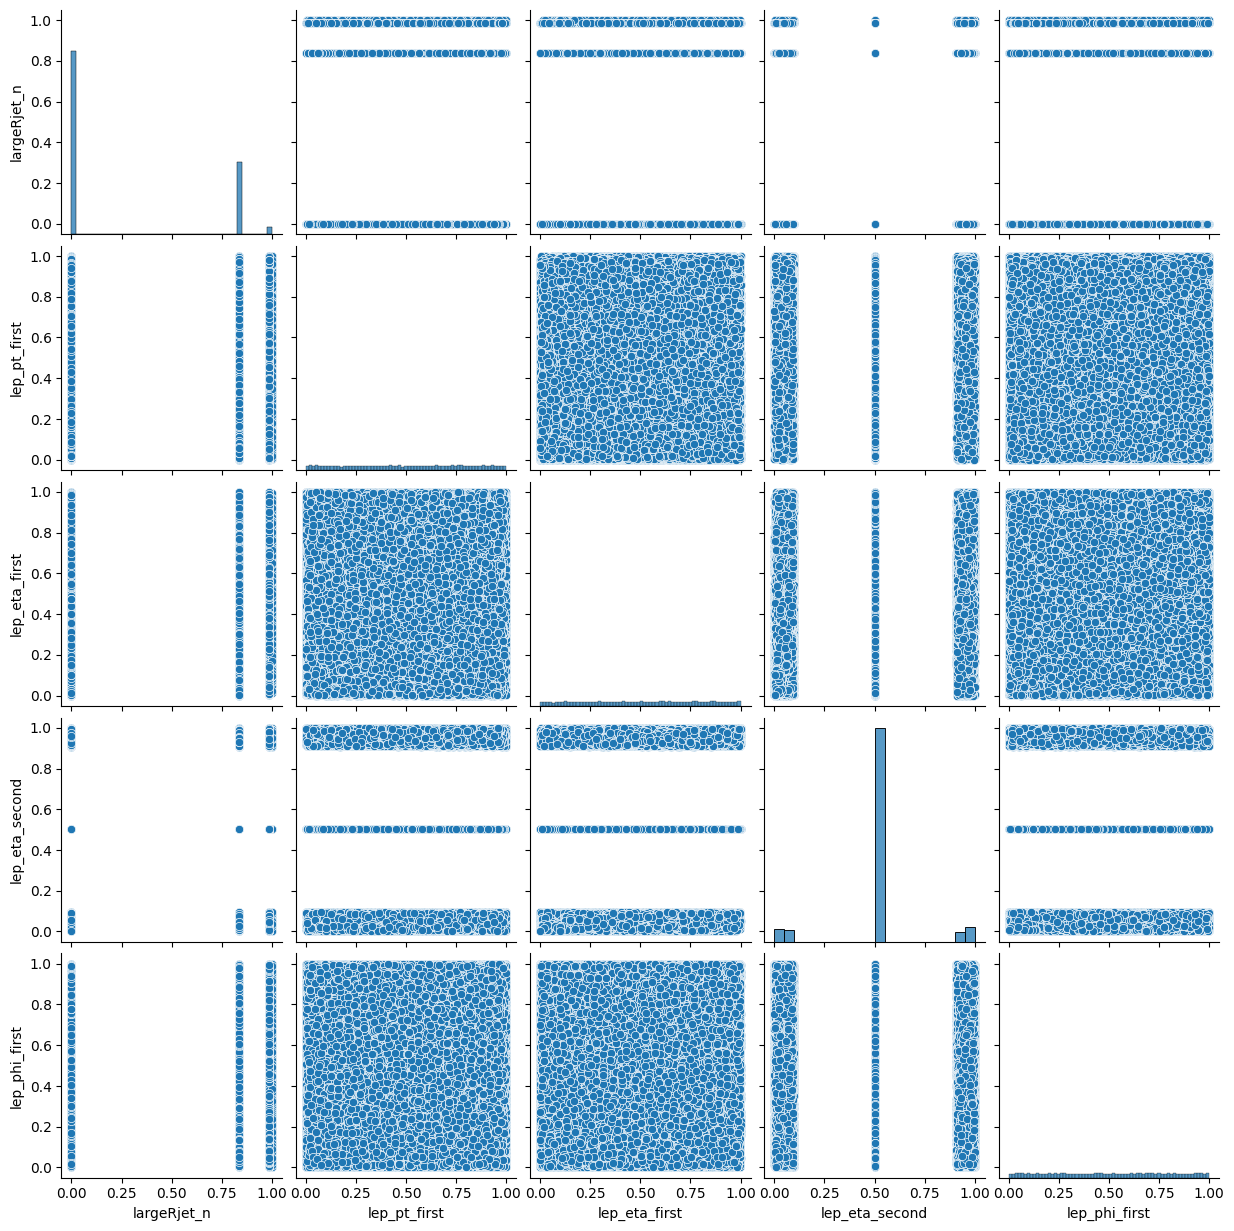

In [5]:
from sklearn.preprocessing import QuantileTransformer

#TODO: Do not plot heatmap next time cause that shit takes forever
qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000) #TODO: try uniform distribution
X_scaled = qt.fit_transform(df_extracted)

sns.pairplot(df_extracted.iloc[:,5:10])
plt.show()
Xdf = pd.DataFrame(X_scaled, columns=df_extracted.columns)
sns.pairplot(Xdf.iloc[:,5:10])
plt.show()

## PCA (dimentional reduction)

In [6]:
# from sklearn.decomposition import PCA
# pca = PCA(n_components=0.98)  # Keep 98% of variance
# X_pca = pca.fit_transform(X_scaled)

In [7]:
# X_pca.shape

## Splitting and Training

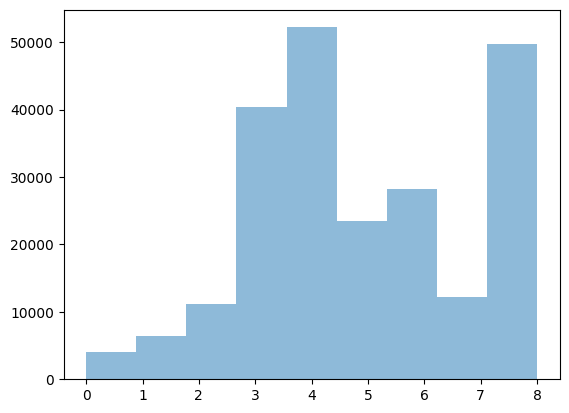

In [8]:
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, df['numeric_target'], test_size=0.2, random_state=123, stratify=df['numeric_target'])

num_classes = len(df['numeric_target'].unique())
plt.hist(y_train, bins=num_classes, alpha=0.5, label='Train')
plt.show()

<BarContainer object of 9 artists>

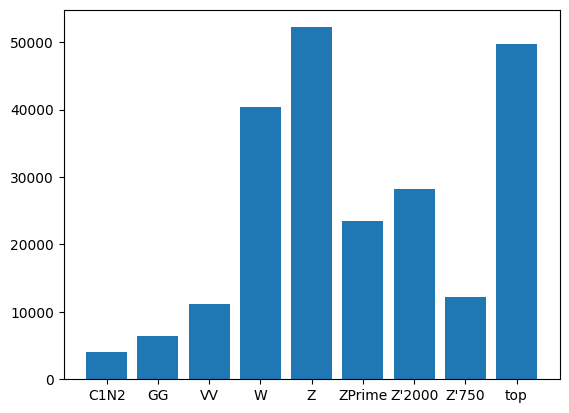

In [9]:
a, c = np.unique(y_train, return_counts=True)
event_names = np.unique(df.event_type)
event_names = [event if event[:2] != 'Zp' else "Z'" + event.split('e')[1] for event in event_names]
plt.bar(event_names, c)

## SAFE LEVEL SMOTE

Setting this up was very funky, but it should work fine now.


NOTE: seems very useful but takes forever to run and sometimes it just gets stuck...  thus will be skipped for now

In [10]:
# from crucio import SLS
# from collections import Counter
# from tqdm import tqdm
# import time

# # Check class distribution before balancing
# print("Class distribution before balancing:")
# print(Counter(y_train))

# # Fix: Use the correct column names that match X_train
# remaining_columns = df_extracted.columns.tolist()

# # Create DataFrame with correct column names
# X_df = pd.DataFrame(X_train, columns=remaining_columns)
# X_df['y_train'] = y_train

# print(f"X_train shape: {X_train.shape}")
# print(f"df_extracted columns: {len(df_extracted.columns)}")
# print(f"X_df shape: {X_df.shape}")

# # Initialize SLS with timeout
# sls = SLS()

# # Balance the dataset with timeout and progress tracking
# print("Starting SLS balancing... (this may take a while)")
# start_time = time.time()
# timeout_seconds = 300  # 5 minutes timeout

# try:
#     # Create a progress bar
#     with tqdm(desc="SLS Progress", unit="iterations") as pbar:
#         X_balanced = sls.balance(X_df, 'y_train')
#         pbar.update(1)
    
#     print("SLS balancing successful!")
#     print(f"Balanced dataset shape: {X_balanced.shape}")
    
#     # Check class distribution after balancing
#     print("Class distribution after balancing:")
#     print(Counter(X_balanced['y_train']))
    
# except Exception as e:
#     elapsed_time = time.time() - start_time
#     print(f"SLS failed after {elapsed_time:.1f} seconds: {e}")
#     print("Falling back to regular SMOTE (much faster)...")
    
#     # Use regular SMOTE as fallback
#     from imblearn.over_sampling import SMOTE
    
#     with tqdm(desc="SMOTE Progress", total=100) as pbar:
#         smote = SMOTE(random_state=42)
#         pbar.update(25)
        
#         X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
#         pbar.update(50)
        
#         # Create balanced DataFrame
#         X_balanced = pd.DataFrame(X_train_balanced, columns=remaining_columns)
#         X_balanced['y_train'] = y_train_balanced
#         pbar.update(25)
    
#     print("SMOTE balancing successful!")
#     print(f"Balanced dataset shape: {X_balanced.shape}")
#     print("Class distribution after balancing:")
#     print(Counter(X_balanced['y_train']))

## Class Weights 

helps fix the imbalance in the data


MADE EVERYTHING WORSE

In [11]:
# # class weighting
# from sklearn.utils.class_weight import compute_class_weight
# class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
# class_weight_dict = dict(zip(np.unique(y_train), class_weights))
# print("Class weights:", class_weight_dict)

## OVER SAMPLING

In [12]:
# from imblearn.over_sampling import RandomOverSampler

# # Basic random oversampling
# ros = RandomOverSampler(random_state=42)

# X_train_balanced, y_train_balanced = ros.fit_resample(X_train, y_train)

# plt.hist(y_train_balanced, bins=num_classes, alpha=0.5, label='Train Balanced')

# X_train = X_train_balanced
# y_train = y_train_balanced

## Simple Dense Model

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
# Define the model
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
# model.add(Dropout(0.2))
# model.add(Dense(32, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

ES = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=200, batch_size=32, validation_split=0.2, verbose=1, callbacks=[ES])

Epoch 1/200
5698/5698 ━━━━━━━━━━━━━━━━━━━━ 48s 8ms/step - accuracy: 0.4695 - loss: 1.4113 - val_accuracy: 0.5422 - val_loss: 1.2086
Epoch 2/200
5698/5698 ━━━━━━━━━━━━━━━━━━━━ 42s 7ms/step - accuracy: 0.5335 - loss: 1.2347 - val_accuracy: 0.5649 - val_loss: 1.1391
Epoch 3/200
5698/5698 ━━━━━━━━━━━━━━━━━━━━ 42s 7ms/step - accuracy: 0.5479 - loss: 1.1961 - val_accuracy: 0.5702 - val_loss: 1.1344
Epoch 4/200
5698/5698 ━━━━━━━━━━━━━━━━━━━━ 42s 7ms/step - accuracy: 0.5553 - loss: 1.1778 - val_accuracy: 0.5775 - val_loss: 1.1227
Epoch 5/200
5698/5698 ━━━━━━━━━━━━━━━━━━━━ 43s 7ms/step - accuracy: 0.5588 - loss: 1.1678 - val_accuracy: 0.5789 - val_loss: 1.1279
Epoch 6/200
5698/5698 ━━━━━━━━━━━━━━━━━━━━ 45s 8ms/step - accuracy: 0.5622 - loss: 1.1591 - val_accuracy: 0.5873 - val_loss: 1.0941
Epoch 7/200
5698/5698 ━━━━━━━━━━━━━━━━━━━━ 42s 7ms/step - accuracy: 0.5643 - loss: 1.1552 - val_accuracy: 0.5908 - val_loss: 1.0864
Epoch 8/200
5698/5698 ━━━━━━━━━━━━━━━━━━━━ 42s 7ms/step - accuracy: 0.5655 -

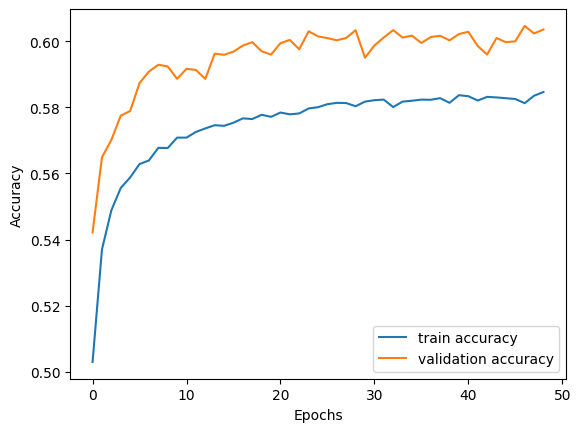

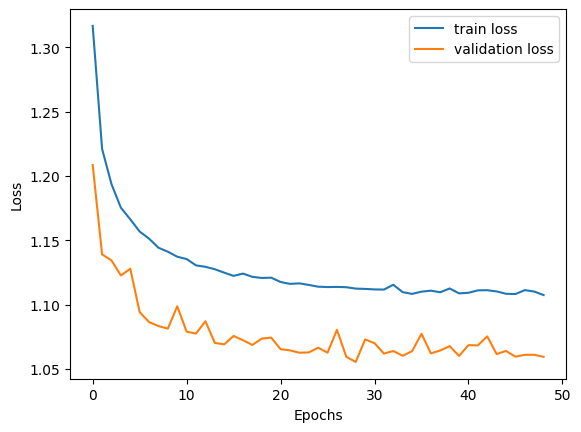

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.81      0.80      1002
           1       0.74      0.75      0.75      1600
           2       0.35      0.03      0.06      2800
           3       0.54      0.66      0.59     10089
           4       0.69      0.62      0.65     13050
           5       0.53      0.57      0.55      5885
           6       0.73      0.77      0.75      7071
           7       0.42      0.38      0.40      3060
           8       0.56      0.60      0.58     12414

    accuracy                           0.60     56971
   macro avg       0.59      0.58      0.57     56971
weighted avg       0.59      0.60      0.59     56971

F1 Score: 0.5891373274531871
Accuracy Score: 0.6012181636271086


In [16]:
###############
#plotting#

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

from sklearn.metrics import classification_report, f1_score, accuracy_score
# Evaluate the model on the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))
print("F1 Score:", f1_score(y_test, y_pred_classes, average='weighted'))
print("Accuracy Score:", accuracy_score(y_test, y_pred_classes))

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


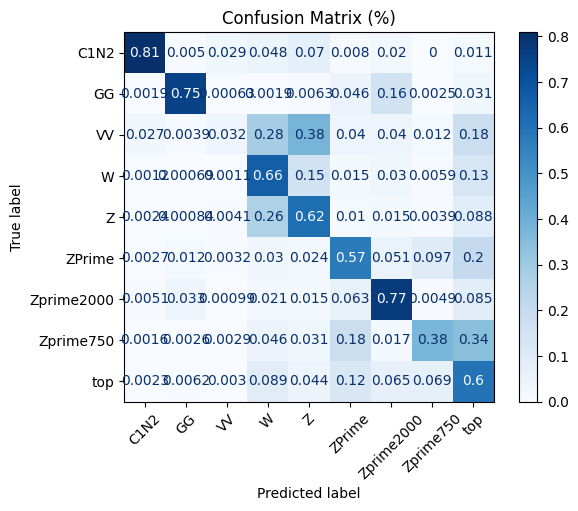

In [17]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_classes, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=event_target_mapping['event_type'])
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix (%)')
plt.show()


## CNN model

Epoch 1/50
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 61s 20ms/step - accuracy: 0.5105 - loss: 1.2063 - val_accuracy: 0.5809 - val_loss: 0.9885
Epoch 2/50
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 58s 20ms/step - accuracy: 0.5708 - loss: 1.0096 - val_accuracy: 0.5931 - val_loss: 0.9570
Epoch 3/50
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 55s 19ms/step - accuracy: 0.5827 - loss: 0.9814 - val_accuracy: 0.5925 - val_loss: 0.9303
Epoch 4/50
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 58s 20ms/step - accuracy: 0.5935 - loss: 0.9517 - val_accuracy: 0.5977 - val_loss: 0.9201
Epoch 5/50
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 55s 19ms/step - accuracy: 0.5942 - loss: 0.9453 - val_accuracy: 0.6059 - val_loss: 0.9325
Epoch 6/50
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 58s 20ms/step - accuracy: 0.5986 - loss: 0.9395 - val_accuracy: 0.6019 - val_loss: 0.9161
Epoch 7/50
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 58s 20ms/step - accuracy: 0.6048 - loss: 0.9301 - val_accuracy: 0.6069 - val_loss: 0.9043
Epoch 8/50
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 55s 19ms/step - accuracy: 0.6069 -

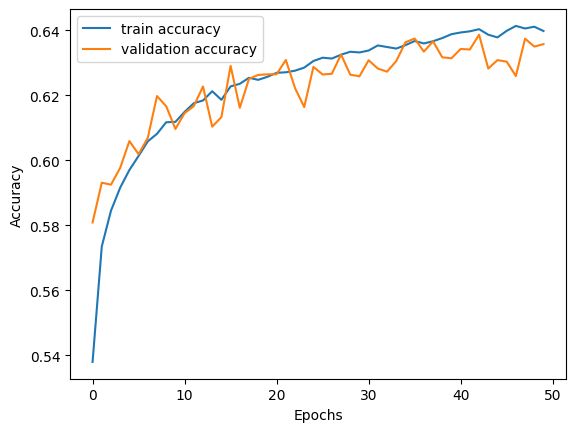

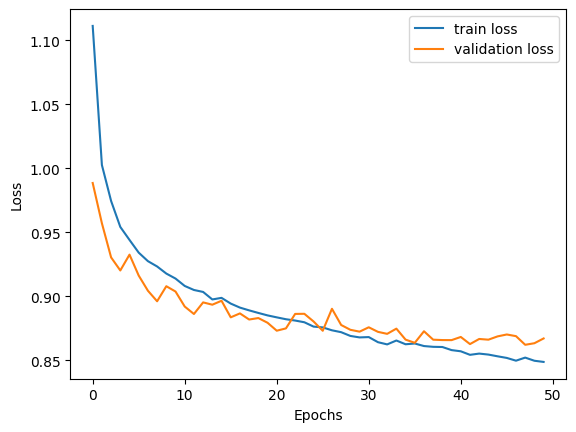

In [11]:
from tensorflow.keras.layers import Conv1D, BatchNormalization, Dense, Input, GlobalMaxPool1D
from tensorflow.keras import models

# Define the CNN model
cnn_model = models.Sequential()
cnn_model.add(Input(shape=(X_train.shape[1], 1)))  # Reshape input to 2D
cnn_model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(Dropout(0.2))

cnn_model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(Dropout(0.2))

cnn_model.add(Conv1D(256, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(GlobalMaxPool1D())

cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.2))
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(num_classes, activation='softmax'))

# Compile the CNN model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the CNN model
history_cnn = cnn_model.fit(X_train.reshape(X_train.shape[0], X_train.shape[1], 1), y_train,
                            epochs=50, batch_size=32, validation_split=0.2, verbose=1)


# Plot CNN training history

plt.plot(history_cnn.history['accuracy'], label='train accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
plt.plot(history_cnn.history['loss'], label='train loss')
plt.plot(history_cnn.history['val_loss'], label='validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## BDT

[0]	validation_0-mlogloss:2.05663	validation_1-mlogloss:2.05707
[1]	validation_0-mlogloss:1.94650	validation_1-mlogloss:1.94770
[2]	validation_0-mlogloss:1.85941	validation_1-mlogloss:1.86093
[3]	validation_0-mlogloss:1.78604	validation_1-mlogloss:1.78812
[4]	validation_0-mlogloss:1.72001	validation_1-mlogloss:1.72284
[5]	validation_0-mlogloss:1.66236	validation_1-mlogloss:1.66590
[6]	validation_0-mlogloss:1.61155	validation_1-mlogloss:1.61580
[7]	validation_0-mlogloss:1.56793	validation_1-mlogloss:1.57277
[8]	validation_0-mlogloss:1.52969	validation_1-mlogloss:1.53519
[9]	validation_0-mlogloss:1.49385	validation_1-mlogloss:1.49999
[10]	validation_0-mlogloss:1.46155	validation_1-mlogloss:1.46835
[11]	validation_0-mlogloss:1.43262	validation_1-mlogloss:1.44004
[12]	validation_0-mlogloss:1.40641	validation_1-mlogloss:1.41455
[13]	validation_0-mlogloss:1.38305	validation_1-mlogloss:1.39179
[14]	validation_0-mlogloss:1.36127	validation_1-mlogloss:1.37061
[15]	validation_0-mlogloss:1.34083	

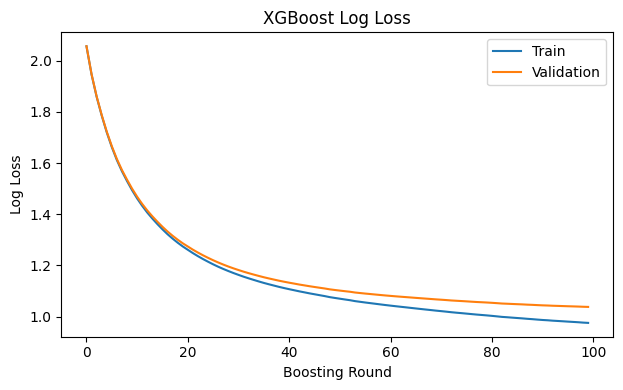

In [21]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report


model = xgb.XGBClassifier(
    objective='multi:softprob',  # Multi-class classification
    n_estimators=100,           # Number of boosting rounds (like epochs)
    max_depth=6,               # Maximum tree depth
    learning_rate=0.1,         # Learning rate (like optimizer step size)
    subsample=0.8,             # Fraction of samples used for training each tree
    colsample_bytree=0.8,      # Fraction of features used for each tree
    random_state=123,          # For reproducibility
    eval_metric='mlogloss',    # Multi-class log loss
    early_stopping_rounds=50,   # Stop if no improvement for 10 rounds
    verbosity=1
)

# Train the model (corrected parameters)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=True
)

# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

# Plot training history
results = model.evals_result()
epochs = len(results['validation_0']['mlogloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x_axis, results['validation_0']['mlogloss'], label='Train')
plt.plot(x_axis, results['validation_1']['mlogloss'], label='Validation')
plt.ylabel('Log Loss')
plt.xlabel('Boosting Round')
plt.title('XGBoost Log Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Hyper Parameter Optimization

Simple Denes Model

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


#hyper parameters to optimize

learning_rate = [0.01, 0.001, 0.0001]  # Example learning rates to try
dropout = [0.1, 0.25, 0.5] 


Histories = [['Dropout', 'learning rate', 'history']]  # Store histories for each combination

for D in dropout:
    for lr in learning_rate:
        print(f"Training with dropout={D} and learning_rate={lr}")
        # Define the model
        model = Sequential()
        model.add(Input(shape=(X_train.shape[1],)))
        model.add(Dense(128, activation='relu'))
        model.add(Dropout(D))
        model.add(Dense(256, activation='relu'))
        model.add(Dropout(D))
        model.add(Dense(128, activation='relu'))
        model.add(Dropout(D))
        model.add(Dense(64, activation='relu'))
        model.add(Dropout(D))
        model.add(Dense(32, activation='relu'))
        model.add(Dense(num_classes, activation='softmax'))

        # Compile the model
        model.compile(optimizer=Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        ES = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

        # Train the model
        history = model.fit(X_train, y_train, epochs=200, batch_size=32, validation_split=0.2, verbose=1, callbacks=[ES])
        Histories.append((D, lr, history))

Training with dropout=0.1 and learning_rate=0.01
Epoch 1/200
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.5227 - loss: 1.1299 - val_accuracy: 0.5615 - val_loss: 1.0250
Epoch 2/200
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.5491 - loss: 1.0565 - val_accuracy: 0.5727 - val_loss: 1.0032
Epoch 3/200
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.5610 - loss: 1.0423 - val_accuracy: 0.5795 - val_loss: 0.9895
Epoch 4/200
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.5658 - loss: 1.0381 - val_accuracy: 0.5735 - val_loss: 0.9998
Epoch 5/200
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.5658 - loss: 1.0305 - val_accuracy: 0.5735 - val_loss: 1.0012
Epoch 6/200
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.5685 - loss: 1.0326 - val_accuracy: 0.5735 - val_loss: 1.0293
Epoch 7/200
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.5574 - loss: 1.0561 - val_accuracy: 0.5675 - val_loss: 1.0192
Epoch 8/200
2880/2880 ━━━━━

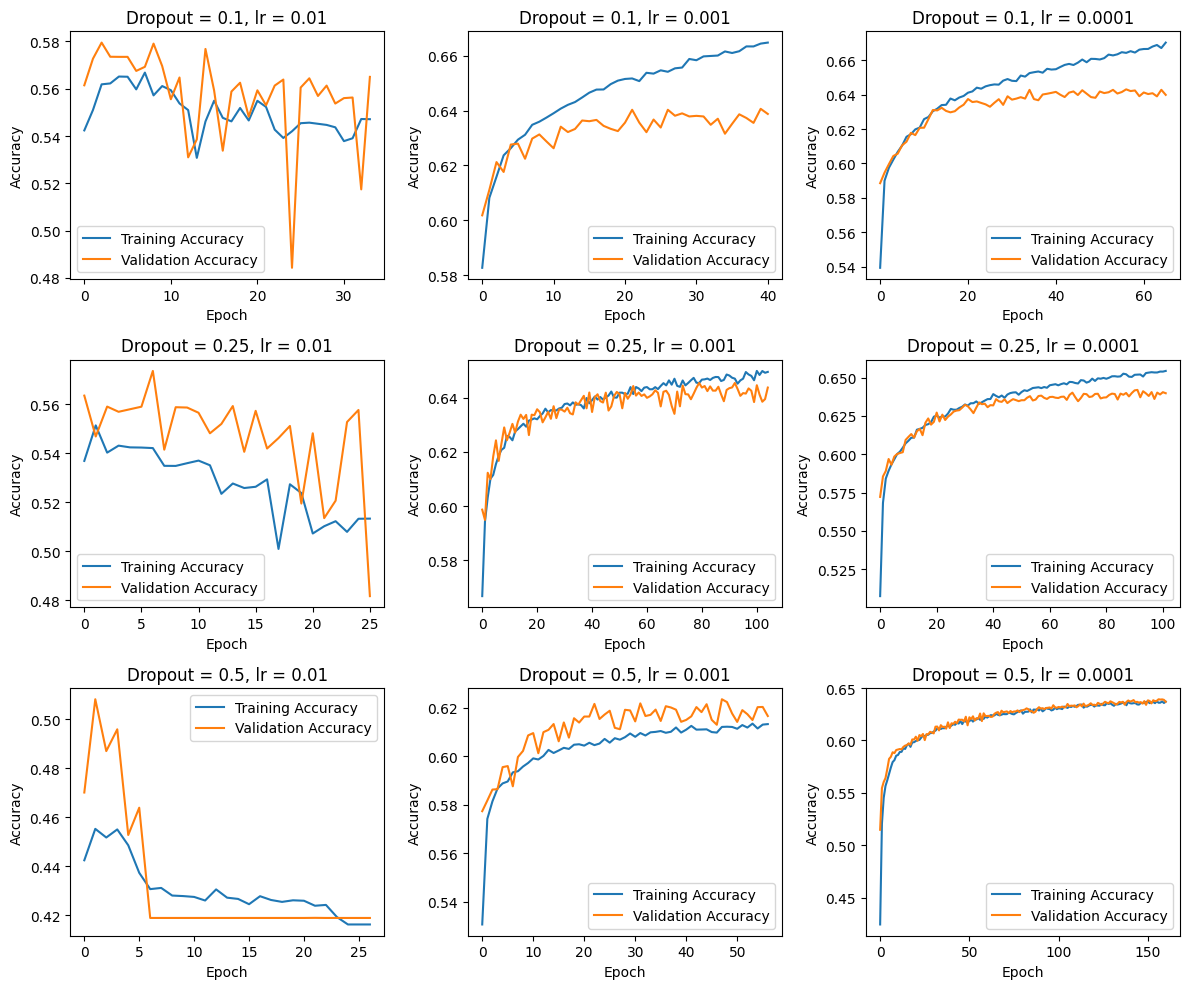

In [19]:
# Plotting Histories
fig, ax = plt.subplots(3, 3, figsize=(12, 10))
ax = ax.flatten()  # Convert 2D array to 1D for easier indexing

for i, H in enumerate(Histories[1:]):
    if i >= 9:  # Safety check for 3x3 grid
        break
    ax[i].plot(H[2].history['accuracy'], label='Training Accuracy')
    ax[i].plot(H[2].history['val_accuracy'], label='Validation Accuracy')
    ax[i].legend()
    ax[i].set_title(f'Dropout = {H[0]}, lr = {H[1]}')
    ax[i].set_xlabel('Epoch')
    ax[i].set_ylabel('Accuracy')

# Hide unused subplots if you have fewer than 9 models
for j in range(len(Histories[1:]), 9):
    ax[j].set_visible(False)

plt.tight_layout()
plt.show()

In [85]:
def get_stable_val_accuracy(val_acc, method='mean_around_peak', window=5):
    """Get a stable validation accuracy metric that's less sensitive to fluctuations"""
    
    if method == 'mean_around_peak':
        maxindex = np.argmax(val_acc)
        # Safe indexing to avoid out-of-bounds
        start_idx = max(0, maxindex - window)
        end_idx = min(len(val_acc), maxindex + window + 1)
        
        stable_acc = np.mean(val_acc[start_idx:end_idx])
        stability_std = np.std(val_acc[start_idx:end_idx])
        
    return stable_acc, stability_std

# Extract data for plotting
dropout_rates = []
learning_rates = []
val_accuracies = []
std_values = []

for i, H in enumerate(Histories[1:]):
    if i >= 9:
        break
    
    # Extract hyperparameters
    dropout_rate = H[0]  # First hyperparameter
    learning_rate = H[1]  # Second hyperparameter
    
    # Get validation accuracy
    val_acc = H[2].history['val_accuracy']
    stable_acc, stability_std = get_stable_val_accuracy(val_acc, method='mean_around_peak', window=5)
    
    dropout_rates.append(dropout_rate)
    learning_rates.append(learning_rate)
    val_accuracies.append(stable_acc)
    std_values.append(stability_std)

# Convert to numpy arrays
dropout_rates = np.array(dropout_rates)
learning_rates = np.array(learning_rates)
val_accuracies = np.array(val_accuracies)
std_values = np.array(std_values)


print(f'dropouts = {dropout_rates}')
print(f'learning_rates = {learning_rates}')
print(f'val acc = {val_accuracies}')
print(f'std = {std_values}')

dropouts = [0.1  0.1  0.1  0.25 0.25 0.25 0.5  0.5  0.5 ]
learning_rates = [0.01   0.001  0.0001 0.01   0.001  0.0001 0.01   0.001  0.0001]
val acc = [0.57137045 0.63678695 0.64142992 0.5560251  0.64263336 0.63973327
 0.47091393 0.6183436  0.63795573]
std = [0.00498749 0.00277611 0.00110939 0.00799861 0.00166471 0.00153344
 0.0276917  0.00323212 0.00116028]


Text(0, 0.5, 'Val Accuracy')

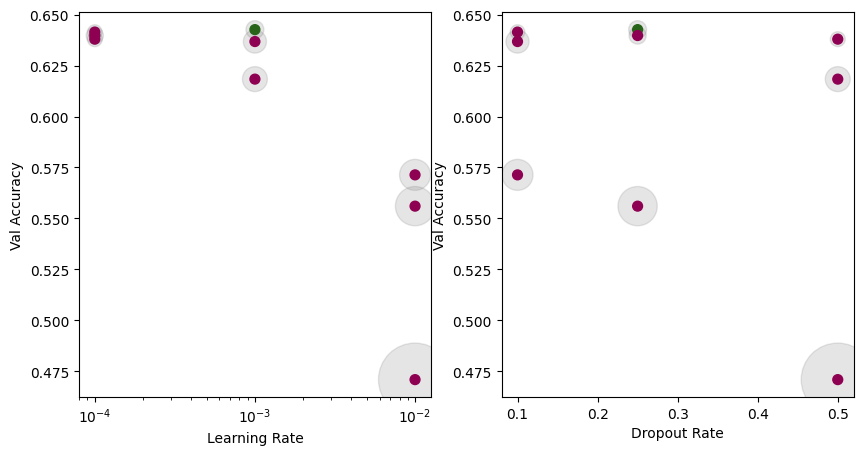

In [105]:
### for saving lol
# dropouts = [0.1  0.1  0.1  0.25 0.25 0.25 0.5  0.5  0.5 ]
# learning_rates = [0.01   0.001  0.0001 0.01   0.001  0.0001 0.01   0.001  0.0001]
# val acc = [0.57137045 0.63678695 0.64142992 0.5560251  0.64263336 0.63973327
#  0.47091393 0.6183436  0.63795573]
# std = [0.00498749 0.00277611 0.00110939 0.00799861 0.00166471 0.00153344
#  0.0276917  0.00323212 0.00116028]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(learning_rates, val_accuracies, alpha = 0.2, s = 10e4*std_values, color = 'grey', label = 'std')
c = (np.ones(val_accuracies.size) + (val_accuracies == np.max(val_accuracies)))
ax[0].scatter(learning_rates, val_accuracies, s = 50, c=c, cmap='PiYG')
ax[0].set_xlabel('Learning Rate')
ax[0].set_ylabel('Val Accuracy')
ax[0].set_xscale('log')

ax[1].scatter(dropout_rates, val_accuracies, alpha = 0.2, s = 10e4*std_values, color = 'grey', label = 'std')
c = (np.ones(val_accuracies.size) + (val_accuracies == np.max(val_accuracies)))
ax[1].scatter(dropout_rates, val_accuracies, s = 50, c=c, cmap='PiYG')
ax[1].set_xlabel('Dropout Rate')
ax[1].set_ylabel('Val Accuracy')
# ax[1].xscale('log')


In [77]:
(val_accuracies == np.max(val_accuracies)) +1

array([1, 1, 1, 1, 2, 1, 1, 1, 1])

# CNN hyper parameter opt

In [10]:
from tensorflow.keras.layers import Conv1D, BatchNormalization, Dense, Input, GlobalMaxPool1D
from tensorflow.keras import models


#optimizing hyperparams

kernal_sizes = [3, 5, 10]  # Example kernel sizes to try
learning_rate = [0.01, 0.001, 0.0001]  # Example learning rates to try
dropout = [0.1, 0.25, 0.5] 

k_size_hist = []

for k in kernal_sizes:
# Define the CNN model
    cnn_model = models.Sequential()
    cnn_model.add(Input(shape=(X_train.shape[1], 1)))  # Reshape input to 2D
    cnn_model.add(Conv1D(64, kernel_size=k, activation='relu', padding='same'))
    cnn_model.add(BatchNormalization())
    cnn_model.add(Dropout(0.2))

    cnn_model.add(Conv1D(128, kernel_size=k, activation='relu', padding='same'))
    cnn_model.add(BatchNormalization())
    cnn_model.add(Dropout(0.2))

    cnn_model.add(Conv1D(256, kernel_size=k, activation='relu', padding='same'))
    cnn_model.add(BatchNormalization())
    cnn_model.add(GlobalMaxPool1D())

    cnn_model.add(Dense(128, activation='relu'))
    cnn_model.add(Dropout(0.2))
    cnn_model.add(Dense(64, activation='relu'))
    cnn_model.add(Dense(num_classes, activation='softmax'))

    # Compile the CNN model
    cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Train the CNN model
    history_cnn = cnn_model.fit(X_train.reshape(X_train.shape[0], X_train.shape[1], 1), y_train,
                                epochs=50, batch_size=32, validation_split=0.2, verbose=1)
    
    k_size_hist.append((k, history_cnn))




Epoch 1/50
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 65s 21ms/step - accuracy: 0.5113 - loss: 1.2124 - val_accuracy: 0.5696 - val_loss: 1.0226
Epoch 2/50
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 58s 20ms/step - accuracy: 0.5669 - loss: 1.0124 - val_accuracy: 0.5790 - val_loss: 0.9607
Epoch 3/50
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 60s 21ms/step - accuracy: 0.5809 - loss: 0.9777 - val_accuracy: 0.5858 - val_loss: 0.9575
Epoch 4/50
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 59s 21ms/step - accuracy: 0.5846 - loss: 0.9654 - val_accuracy: 0.6054 - val_loss: 0.9282
Epoch 5/50
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 59s 20ms/step - accuracy: 0.5943 - loss: 0.9511 - val_accuracy: 0.6110 - val_loss: 0.9039
Epoch 6/50
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 59s 20ms/step - accuracy: 0.5989 - loss: 0.9356 - val_accuracy: 0.6005 - val_loss: 0.9216
Epoch 7/50
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 59s 20ms/step - accuracy: 0.5994 - loss: 0.9301 - val_accuracy: 0.6052 - val_loss: 0.9022
Epoch 8/50
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 59s 20ms/step - accuracy: 0.6045 -

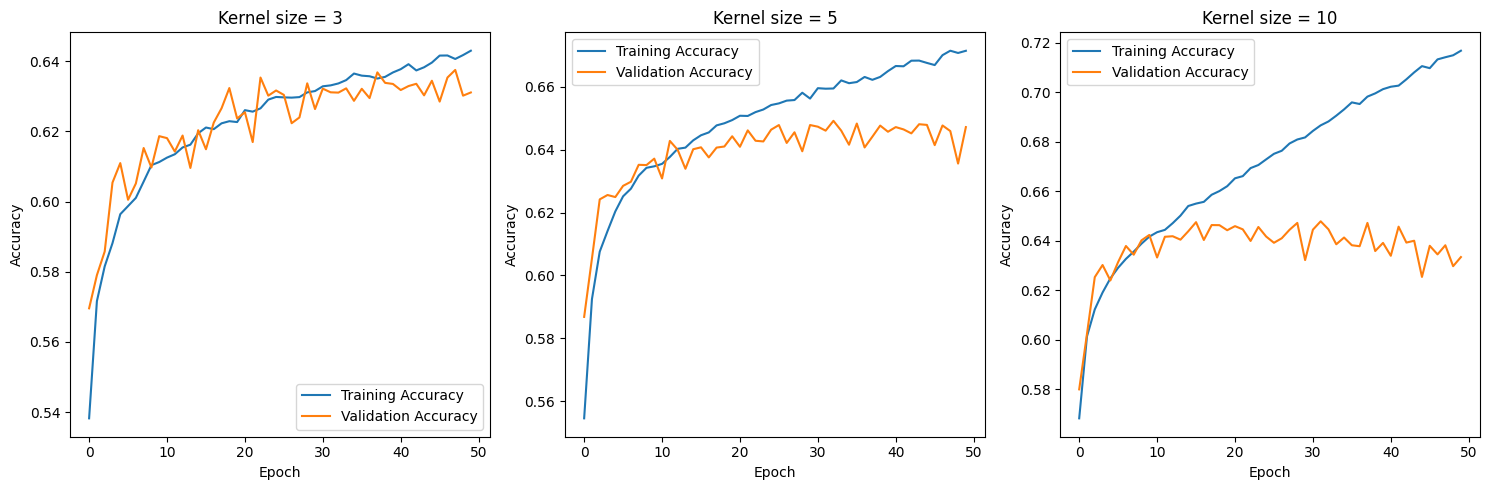

In [93]:
#extract best k size and use it later
k_size_hist

# Plotting Histories
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax = ax.flatten()  # Convert 2D array to 1D for easier indexing

for i, H in enumerate(k_size_hist[:]):
    if i >= 3:  # Safety check for 3x3 grid
        break
    ax[i].plot(H[1].history['accuracy'], label='Training Accuracy')
    ax[i].plot(H[1].history['val_accuracy'], label='Validation Accuracy')
    ax[i].legend()
    ax[i].set_title(f'Kernel size = {H[0]}')
    ax[i].set_xlabel('Epoch')
    ax[i].set_ylabel('Accuracy')

# Hide unused subplots if you have fewer than 9 models
for j in range(len(Histories[1:]), 9):
    ax[j].set_visible(False)

plt.tight_layout()
plt.show()

In [95]:

k_val_acc = []
k_std = []
for i, H in enumerate(k_size_hist[:]):
    if i >= 3:
        break
    
    # Extract hyperparameters
    # dropout_rate = H[0]  # First hyperparameter
    # learning_rate = H[1]  # Second hyperparameter
    
    # Get validation accuracy
    val_acc = H[1].history['val_accuracy']
    stable_acc, stability_std = get_stable_val_accuracy(val_acc, method='mean_around_peak', window=5)
    
    # dropout_rates.append(dropout_rate)
    # learning_rates.append(learning_rate)
    k_val_acc.append(stable_acc)
    k_std.append(stability_std)

# Convert to numpy arrays
k_val_acc = np.array(k_val_acc)
k_std = np.array(k_std)

print(f'k val acc = {k_val_acc}')
print(f'std = {k_std}')

k val acc = [0.63263888 0.64506392 0.64161538]
std = [0.00288261 0.00309228 0.00447505]


(0.63, 0.647)

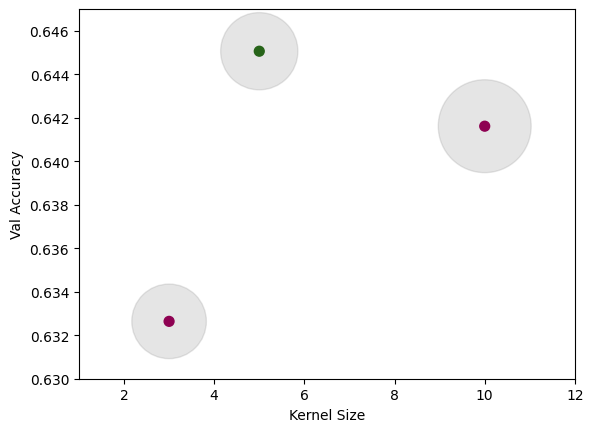

In [101]:
plt.scatter(kernal_sizes, k_val_acc, alpha = 0.2, s = 10e5*k_std, color = 'grey', label = 'std')
c = (np.ones(k_val_acc.size) + (k_val_acc == np.max(k_val_acc)))
plt.scatter(kernal_sizes, k_val_acc, s = 50, c=c, cmap='PiYG')
plt.xlabel('Kernel Size')
plt.ylabel('Val Accuracy')
plt.xlim(1,12)
plt.ylim(0.630, 0.647)
#plt.xscale('log')

In [ ]:

learn_rate_hist = []


for lr in learning_rate:
    # Define the model
    cnn_model = models.Sequential()
    cnn_model.add(Input(shape=(X_train.shape[1], 1)))  # Reshape input to 2D
    cnn_model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
    cnn_model.add(BatchNormalization())
    cnn_model.add(Dropout(0.2))

    cnn_model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
    cnn_model.add(BatchNormalization())
    cnn_model.add(Dropout(0.2))

    cnn_model.add(Conv1D(256, kernel_size=3, activation='relu', padding='same'))
    cnn_model.add(BatchNormalization())
    cnn_model.add(GlobalMaxPool1D())

    cnn_model.add(Dense(128, activation='relu'))
    cnn_model.add(Dropout(0.2))
    cnn_model.add(Dense(64, activation='relu'))
    cnn_model.add(Dense(num_classes, activation='softmax'))

    # Compile the CNN model
    cnn_model.compile(optimizer=Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Train the CNN model
    history_cnn = cnn_model.fit(X_train.reshape(X_train.shape[0], X_train.shape[1], 1), y_train,
                                epochs=50, batch_size=32, validation_split=0.2, verbose=1)
    
    learn_rate_hist.append((lr, history_cnn))




In [ ]:
#extract best lr and use it later

In [ ]:

dropout_hist = []

for D in dropout:
    # Define the model
    cnn_model = models.Sequential()
    cnn_model.add(Input(shape=(X_train.shape[1], 1)))  # Reshape input to 2D
    cnn_model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
    cnn_model.add(BatchNormalization())
    cnn_model.add(Dropout(D))

    cnn_model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
    cnn_model.add(BatchNormalization())
    cnn_model.add(Dropout(D))

    cnn_model.add(Conv1D(256, kernel_size=3, activation='relu', padding='same'))
    cnn_model.add(BatchNormalization())
    cnn_model.add(GlobalMaxPool1D())

    cnn_model.add(Dense(128, activation='relu'))
    cnn_model.add(Dropout(D))
    cnn_model.add(Dense(64, activation='relu'))
    cnn_model.add(Dense(num_classes, activation='softmax'))

    # Compile the CNN model
    cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Train the CNN model
    history_cnn = cnn_model.fit(X_train.reshape(X_train.shape[0], X_train.shape[1], 1), y_train,
                                epochs=50, batch_size=32, validation_split=0.2, verbose=1)
    
    learn_rate_hist.append((D, history_cnn))

In [106]:
print('test')

test


In [107]:
df_extracted

,trigE,lep_n,met_et,met_phi,jet_n,largeRjet_n,lep_pt_first,lep_eta_first,lep_eta_second,lep_phi_first,...,jet_MV2c10_second,largeRjet_eta_second,largeRjet_phi_second,largeRjet_m_first,largeRjet_D2_first,largeRjet_D2_second,largeRjet_tau32_first,largeRjet_tau32_second,jet_eta_mean,jet_phi_mean
0,1,1,359869.0,-0.051272,3,1,111497.0,-0.423384,0.000000,0.318778,...,-0.880717,0.00000,0.00000,22994.0,3.951640,0.0,0.529141,0.0,-0.019711,0.136268
1,1,1,269296.0,-0.621126,2,1,61570.4,-0.982475,0.000000,-0.234559,...,-0.873440,0.00000,0.00000,19467.1,1.640630,0.0,0.323550,0.0,-0.130260,0.967138
2,1,1,143828.0,2.869280,1,2,318395.0,-1.283210,0.000000,-3.054040,...,0.000000,-1.30184,-3.05704,36825.7,2.840740,0.0,0.697616,-1.0,-1.073080,0.051057
3,1,1,142210.0,0.676769,1,1,170648.0,0.371647,0.000000,1.162700,...,0.000000,0.00000,0.00000,19505.2,2.646120,0.0,0.631101,0.0,0.372873,-2.203880
4,1,1,217176.0,-1.218040,2,1,60337.0,-2.133360,0.000000,-1.617350,...,-0.746473,0.00000,0.00000,42322.8,2.126380,0.0,0.360752,0.0,-1.018326,1.001834
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169995,0,2,30938.4,0.551938,4,1,217906.0,1.762740,2.354140,0.632238,...,-0.904178,0.00000,0.00000,17547.1,2.272560,0.0,0.510644,0.0,0.880803,0.326102
169996,0,2,36180.5,-0.740489,5,1,165025.0,-1.097250,-1.650290,-2.890850,...,-0.708641,0.00000,0.00000,17452.0,1.754970,0.0,0.509907,0.0,-1.120498,-0.367139
169997,0,2,15057.4,-1.991640,2,1,107048.0,-0.462829,-1.463320,1.670010,...,-0.399890,0.00000,0.00000,13202.9,0.937454,0.0,0.126454,0.0,-0.485333,0.860058
169998,0,2,25064.3,-0.029791,2,1,208895.0,0.384949,0.998916,1.833640,...,-0.815296,0.00000,0.00000,36318.6,2.290940,0.0,0.711334,0.0,-0.277597,-1.741125


In [27]:
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
# model.add(Dense(512, activation='relu'))
# model.add(Dropout(0.2))
# model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])


model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 128)            │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,313 (321.54 KB)

 Trainable params: 82,313 (321.54 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
from tensorflow.keras.layers import Conv1D, BatchNormalization, Dense, Input, GlobalMaxPool1D
from tensorflow.keras import models

cnn_model = models.Sequential()
cnn_model.add(Input(shape=(X_train.shape[1], 1)))  # Reshape input to 2D
cnn_model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(Dropout(0.2))

cnn_model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(Dropout(0.2))

cnn_model.add(Conv1D(256, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(GlobalMaxPool1D())

cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.2))
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(num_classes, activation='softmax'))

# Compile the CNN model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [30]:
cnn_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 44, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 44, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 44, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 44, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 44, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 44, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 44, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 44, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,049 (652.54 KB)

 Trainable params: 166,153 (649.04 KB)

 Non-trainable params: 896 (3.50 KB)

In [37]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model.png', show_shapes=True,show_layer_names=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.
